<a href="https://www.kaggle.com/code/secretiveplotter1863/eda-aapl-next-day-close-prediction-model?scriptVersionId=336964119" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/tarunpaparaju/apple-aapl-historical-stock-data/HistoricalQuotes.csv


Develop and evaluate a single-ticker next-day close prediction model for AAPL using only past price/volume data, with time-based validation and visual analysis of prediction errors.

In [2]:
stock=pd.read_csv('/kaggle/input/datasets/tarunpaparaju/apple-aapl-historical-stock-data/HistoricalQuotes.csv')
stock

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23
...,...,...,...,...,...,...
2513,03/05/2010,$31.2786,224647427,$30.7057,$31.3857,$30.6614
2514,03/04/2010,$30.1014,89591907,$29.8971,$30.1314,$29.8043
2515,03/03/2010,$29.9043,92846488,$29.8486,$29.9814,$29.7057
2516,03/02/2010,$29.8357,141486282,$29.99,$30.1186,$29.6771


In [3]:
print(stock.dtypes)

Date           object
 Close/Last    object
 Volume         int64
 Open          object
 High          object
 Low           object
dtype: object


In [4]:
stock['Date']=pd.to_datetime(stock["Date"], format="%m/%d/%Y")
df_sorted =stock.sort_values(by="Date", ascending=True)
df_sorted

,Date,Close/Last,Volume,Open,High,Low
2517,2010-03-01,$29.8557,137312041,$29.3928,$29.9286,$29.35
2516,2010-03-02,$29.8357,141486282,$29.99,$30.1186,$29.6771
2515,2010-03-03,$29.9043,92846488,$29.8486,$29.9814,$29.7057
2514,2010-03-04,$30.1014,89591907,$29.8971,$30.1314,$29.8043
2513,2010-03-05,$31.2786,224647427,$30.7057,$31.3857,$30.6614
...,...,...,...,...,...,...
4,2020-02-24,$298.18,55548830,$297.26,$304.18,$289.23
3,2020-02-25,$288.08,57668360,$300.95,$302.53,$286.13
2,2020-02-26,$292.65,49678430,$286.53,$297.88,$286.5
1,2020-02-27,$273.52,80151380,$281.1,$286,$272.96


In [5]:
stock.columns = stock.columns.str.strip()

In [6]:
stock.dtypes

Date          datetime64[ns]
Close/Last            object
Volume                 int64
Open                  object
High                  object
Low                   object
dtype: object

In [7]:
stock['High'] = stock['High'].astype(str).str.replace('$', '', regex=False)
stock['High'] = stock['High'].astype(float)
stock['High']

0       278.4100
1       286.0000
2       297.8800
3       302.5300
4       304.1800
          ...   
2513     31.3857
2514     30.1314
2515     29.9814
2516     30.1186
2517     29.9286
Name: High, Length: 2518, dtype: float64

In [8]:
stock['Close/Last'] = stock['Close/Last'].astype(str).str.replace('$', '', regex=False)
stock['Close/Last'] = stock['Close/Last'].astype(float)
stock['Close/Last']

0       273.3600
1       273.5200
2       292.6500
3       288.0800
4       298.1800
          ...   
2513     31.2786
2514     30.1014
2515     29.9043
2516     29.8357
2517     29.8557
Name: Close/Last, Length: 2518, dtype: float64

In [9]:
stock['Open'] = stock['Open'].astype(str).str.replace('$', '', regex=False)
stock['Open'] = stock['Open'].astype(float)
stock['Open']

0       257.2600
1       281.1000
2       286.5300
3       300.9500
4       297.2600
          ...   
2513     30.7057
2514     29.8971
2515     29.8486
2516     29.9900
2517     29.3928
Name: Open, Length: 2518, dtype: float64

In [10]:
stock['Low'] = stock['Low'].astype(str).str.replace('$', '', regex=False)
stock['Low'] = stock['Low'].astype(float)
stock['Low']

0       256.3700
1       272.9600
2       286.5000
3       286.1300
4       289.2300
          ...   
2513     30.6614
2514     29.8043
2515     29.7057
2516     29.6771
2517     29.3500
Name: Low, Length: 2518, dtype: float64

In [11]:
stock.dtypes

Date          datetime64[ns]
Close/Last           float64
Volume                 int64
Open                 float64
High                 float64
Low                  float64
dtype: object

In [12]:
stock = stock.sort_values('Date')

stock['target'] = stock['Close/Last'].shift(-1)

stock['close_lag_1'] = stock['Close/Last'].shift(1)
stock['close_lag_2'] = stock['Close/Last'].shift(2)
stock['close_lag_3'] = stock['Close/Last'].shift(3)
stock['close_lag_5'] = stock['Close/Last'].shift(5)

In [13]:
stock = stock.dropna(subset=['target', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_5'])
x=stock[['close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_5']]
y=stock['target']

In [14]:
#tim based split not random split
split_idx = int(len(stock) * 0.8)

x_train = x.iloc[:split_idx]
x_test  = x.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

date_train=stock['Date'].iloc[:split_idx]
date_test=stock['Date'].iloc[split_idx:]


In [15]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)
y_pred=lin_reg.predict(x_test)

In [16]:
y_pred

array([178.46998394, 178.43197251, 175.2310976 , 176.46866005,
       176.82382308, 176.73843568, 175.22452575, 177.15607723,
       179.97546962, 181.71530435, 180.14720726, 178.77422041,
       178.85832826, 178.07838951, 175.45142872, 175.49587397,
       171.35577984, 169.12263857, 165.12019742, 172.90998087,
       167.99577382, 166.92180333, 168.07596145, 166.62365382,
       168.5599234 , 171.65930384, 172.79802911, 168.59597452,
       170.48527972, 173.2241649 , 172.3730971 , 174.41778683,
       174.84105046, 175.94637298, 178.36807987, 177.90615797,
       173.06032635, 166.17224477, 165.58824256, 162.84140613,
       163.72370266, 164.26204414, 162.40709763, 165.50273388,
       169.05528794, 176.51885119, 176.83321419, 184.17414854,
       185.14487077, 186.28494777, 187.63587948, 190.15397895,
       188.65973884, 188.4465282 , 186.63399379, 188.3463639 ,
       187.00464759, 186.50696739, 187.805403  , 187.19696496,
       188.52819028, 188.25221037, 188.74178646, 188.04

In [17]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import matplotlib.pyplot as plt
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(mae)
print(r2)
print(rmse)


3.826950233357609
0.984204734437056
5.237197229866118


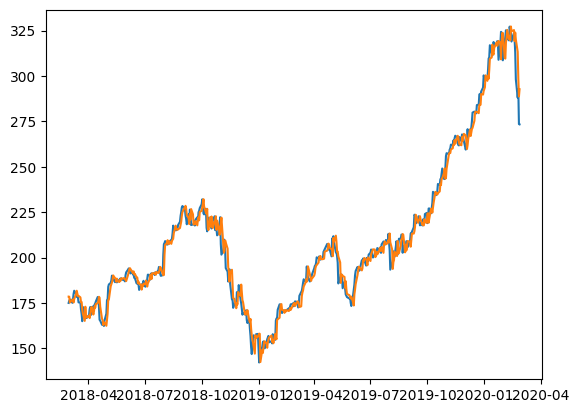

In [18]:
plt.plot(date_test, y_test)
plt.plot(date_test, y_pred)